# Lesson 5: High Dynamic Range (HDR) Imaging

**Description:** 

**Requirement(s):** None

**Author:** Matthew O'Toole

---

In [22]:
import bpy
import bmesh
import numpy as np
import matplotlib.pyplot as plt
import import_ipynb
import itertools

from L001_hello_world import render, clear_scene
from L004_pixel_measurement_model import add_sensor_noise, get_sensor_noise_statistics

# Clear scene
if __name__ == '__main__':
    clear_scene()

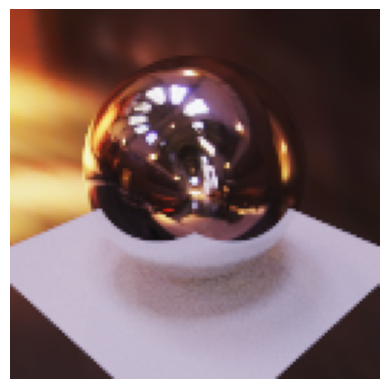

In [23]:
if __name__ == '__main__':
    # Set render engine and resolution for ray tracing
    bpy.context.scene.render.engine = 'CYCLES'
    bpy.context.scene.render.resolution_x = 128
    bpy.context.scene.render.resolution_y = 128
    bpy.context.scene.render.image_settings.file_format = 'HDR'

    # Do not reduce number of samples per pixel based on render noise
    bpy.context.scene.cycles.use_adaptive_sampling = False 

    # Set number of samples to render at each pixel
    bpy.context.scene.cycles.samples = 400

    # Do not denoise the rendered image
    bpy.context.scene.cycles.use_denoising = False

    # Set film filter to box
    bpy.context.scene.cycles.pixel_filter_type = 'BOX'

    # Change camera exposure (in EV steps, default is 0.0)
    bpy.context.scene.cycles.film_exposure = 0.01


    # Create camera
    bpy.ops.object.camera_add(location=(3, -3, 3),
                              rotation=(np.pi*5.5/16, 0, np.pi/4))
    cam = bpy.context.active_object
    bpy.context.scene.camera = cam


    # Add plane to scene
    bpy.ops.mesh.primitive_plane_add(location=(0, 0, 0), 
                                     rotation=(0, 0, 0))
    plane = bpy.context.active_object
    plane.scale = plane.scale * 1.5

    bpy.ops.mesh.primitive_uv_sphere_add(location=(0, 0, 1),
                                         radius=1,
                                         segments=128,
                                         ring_count=64)
    sphere = bpy.context.active_object
    bpy.ops.object.shade_smooth()

    # Add specular material
    specular_material = bpy.data.materials.new(name='Specular Material')

    nodes = specular_material.node_tree.nodes
    bsdf = nodes['Principled BSDF']
    bsdf.inputs['Metallic'].default_value = 1.0
    bsdf.inputs['Roughness'].default_value = 0.0

    sphere.data.materials.append(specular_material)
    
    # Set HDRI environment lighting
    hdri_path = "./hdri/grace_probe.exr"  # Change this to your HDRI file path

    world = bpy.data.worlds.new("HDRI")
    bpy.context.scene.world = world
    nodes = world.node_tree.nodes
    links = world.node_tree.links

    # Clear existing nodes
    nodes.clear()

    # Add nodes for HDRI environment
    bg_node = nodes.new(type='ShaderNodeBackground')
    env_node = nodes.new(type='ShaderNodeTexEnvironment')
    output_node = nodes.new(type='ShaderNodeOutputWorld')

    # Set HDRI file path
    env_node.image = bpy.data.images.load(hdri_path)

    # Position nodes (optional)
    env_node.location = (-300, 0)
    env_node.projection = 'MIRROR_BALL'
    bg_node.location = (0, 0)
    output_node.location = (300, 0)

    # Link nodes
    links.new(env_node.outputs['Color'], bg_node.inputs['Color'])
    links.new(bg_node.outputs['Background'], output_node.inputs['Surface'])


    # Render scene
    bpy.context.scene.cycles.film_exposure = 1
    img = render()
    img = 100 * img / np.max(img)

    def filmic_tonemap(x):
        # x: scene-referred linear input (can be any positive float)
        # Output is mapped to [0, 1]
        a = 0.22
        b = 0.30
        c = 0.10
        d = 0.20
        e = 0.01
        f = 0.30
        return ((x*(a*x+c*b)+d*e)/(x*(a*x+b)+d*f)) - e/f

    # Example usage:
    img_tonemapped = filmic_tonemap(1*img)
    img_tonemapped = np.clip(img_tonemapped, 0, 1)

    plt.imshow(img_tonemapped**(1/2.2), origin='lower')
    plt.axis('off')

In [24]:
def get_hdr(img, exposure=[1/100], iso=[100]):
    a = 0
    b = 0

    for ev, iv in itertools.zip_longest(exposure, iso):
        if (iv == None):
            iv = iso[-1]
        elif (ev == None):
            ev = exposure[-1]

        img_noise = np.clip(add_sensor_noise(img*ev, iso=iv), 0, None)
        img_noise = np.clip(img_noise, 0, 1)
        _, var = get_sensor_noise_statistics(img_noise)
        weight = ev**2 * iv**2 * (img_noise < 0.97) / np.clip(var, 1e-6, None)

        a = a + weight*img_noise/(iv*ev)
        b = b + weight

    img_noise = a / np.clip(b, 1e-9, None)

    return img_noise


(np.float64(-0.5), np.float64(127.5), np.float64(-0.5), np.float64(127.5))

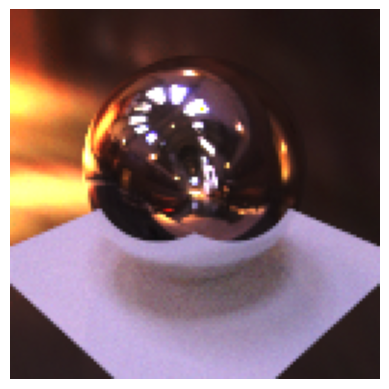

In [25]:
exposure = [1/3200, 1/125, 1/5]
iso = [3200]

plt.imshow(np.clip((get_hdr(img, exposure, iso) * 30)**(1/2.2), 0, 1), origin='lower')
plt.axis('off')

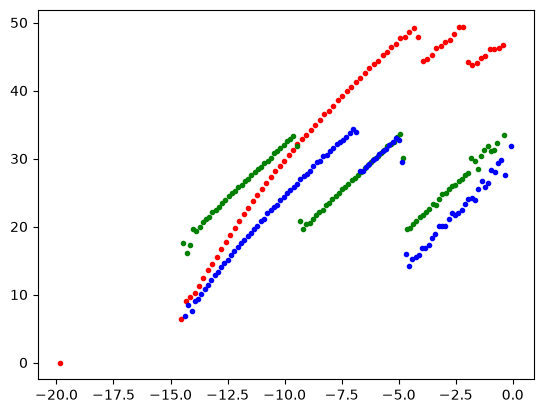

In [26]:
from scipy import stats

stack = []
exposure = [1/100, 1/25, 1/6]
iso = [100]

N = 10
for k in range(N):
    stack.append(get_hdr(img, exposure, iso))

I_mean = 0
I_var = 0

for k in range(N):
    I_mean = I_mean + stack[k]/N

for k in range(N):
    I_var = I_var + (stack[k] - I_mean)**2 / N

I_mean = np.clip(I_mean, 1e-6, None)

I_snr = I_mean / np.clip(np.sqrt(I_var), 1e-6, None)
I_snr = 20 * np.log10(I_snr)

#plt.plot(np.log2(I_mean.reshape(-1)), I_snr.reshape(-1), '.r')

mean_per_bin, bin_edges, binnumber = stats.binned_statistic(np.log2(I_mean.reshape(-1)), I_snr.reshape(-1), statistic='mean', bins=100)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.plot(bin_centers, mean_per_bin, '.r', label='Binned Mean')


stack = []
exposure = [1/3200, 1/125, 1/5]
iso = [3200, 3200, 3200]

for k in range(N):
    stack.append(get_hdr(img, exposure, iso))

I_mean = 0
I_var = 0

for k in range(N):
    I_mean = I_mean + stack[k]/N

for k in range(N):
    I_var = I_var + (stack[k] - I_mean)**2 / N

I_snr = I_mean / np.clip(np.sqrt(I_var), 1e-6, None)
I_snr = 20 * np.log10(I_snr)

mean_per_bin, bin_edges, binnumber = stats.binned_statistic(np.log2(I_mean.reshape(-1)), I_snr.reshape(-1), statistic='mean', bins=100)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.plot(bin_centers, mean_per_bin, '.g', label='Binned Mean')


stack = []
exposure = [1/8000, 1/125, 1/30]
iso = [3200, 3200, 3200]

for k in range(N):
    stack.append(get_hdr(img, exposure, iso))

I_mean = 0
I_var = 0

for k in range(N):
    I_mean = I_mean + stack[k]/N

for k in range(N):
    I_var = I_var + (stack[k] - I_mean)**2 / N

I_snr = I_mean / np.clip(np.sqrt(I_var), 1e-6, None)
I_snr = 20 * np.log10(I_snr)

#plt.plot(np.log2(I_mean.reshape(-1)), I_snr.reshape(-1), '.b')

mean_per_bin, bin_edges, binnumber = stats.binned_statistic(np.log2(I_mean.reshape(-1)), I_snr.reshape(-1), statistic='mean', bins=100)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.plot(bin_centers, mean_per_bin, '.b', label='Binned Mean')

(np.float64(-0.5), np.float64(127.5), np.float64(-0.5), np.float64(127.5))

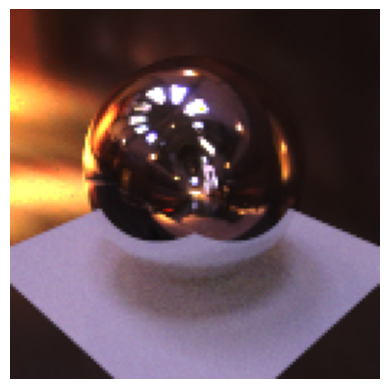

In [27]:
exposure = [1/3200, 1/125, 1/5]
iso = [3200]
get_hdr(img, exposure, iso)

plt.imshow(np.clip((get_hdr(img, exposure, iso) * 20)**(1/2.2), 0, 1), origin='lower')
plt.axis('off')

(np.float64(-0.5), np.float64(127.5), np.float64(-0.5), np.float64(127.5))

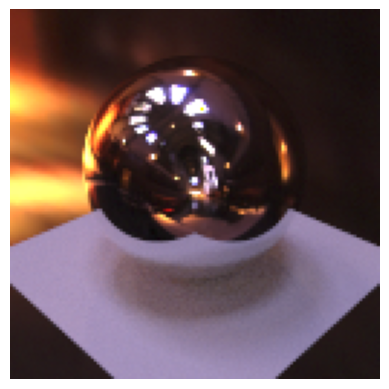

In [28]:
exposure = [1/100, 1/25, 1/6]
iso = [100, 100, 100]
get_hdr(img, exposure, iso)

plt.imshow(np.clip((get_hdr(img, exposure, iso) * 20)**(1/2.2), 0, 1), origin='lower')
plt.axis('off')